In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score

In [4]:
data_matx = [
    [1, 1.8, 0, 120, 9.5, 145, 0.32, 6.5],
    [3, 2.0, 0, 115, 10.2, 158, 0.38, 7.2],
    [5, 2.5, 1, 130, 8.8, 185, 0.45, 8.5],
    [2, 1.6, 0, 110, 11.0, 138, 0.28, 6.0],
    [7, 3.0, 1, 140, 7.5, 220, 0.55, 10.0],
    [4, 2.0, 0, 125, 9.8, 165, 0.40, 7.5],
    [8, 2.2, 2, 100, 11.5, 175, 0.42, 8.0],
    [2, 1.4, 0, 105, 12.0, 125, 0.25, 5.5],
    [6, 2.8, 1, 135, 8.0, 200, 0.50, 9.2],
    [3, 1.8, 0, 118, 10.5, 150, 0.35, 6.8],
    [9, 2.5, 2, 108, 11.2, 190, 0.48, 8.8],
    [1, 2.0, 1, 125, 9.2, 160, 0.39, 7.0],
    [5, 1.6, 0, 112, 10.8, 142, 0.30, 6.2],
    [10, 3.5, 2, 145, 7.0, 280, 0.70, 12.5],
    [2, 2.4, 1, 128, 9.0, 180, 0.44, 8.2],
    [4, 1.8, 0, 115, 10.3, 148, 0.33, 6.6],
    [6, 2.2, 1, 122, 9.5, 170, 0.41, 7.8],
    [3, 1.5, 0, 108, 11.8, 132, 0.27, 5.8],
    [7, 3.2, 2, 138, 7.8, 240, 0.60, 11.0],
    [0, 1.2, 0, 100, 13.0, 110, 0.20, 4.5]
]

data_index = ['Car_Age', 'Engine_Size', 'Fuel_Type', 'Speed', 'Acceleration', 'CO2', 'NOx', 'Fuel_Consumption']
car_names = [f'Car_{i}' for i in range(1, 21)]

df = pd.DataFrame(data_matx, index=car_names, columns=data_index)
print(df)

        Car_Age  Engine_Size  Fuel_Type  Speed  Acceleration  CO2   NOx  \
Car_1         1          1.8          0    120           9.5  145  0.32   
Car_2         3          2.0          0    115          10.2  158  0.38   
Car_3         5          2.5          1    130           8.8  185  0.45   
Car_4         2          1.6          0    110          11.0  138  0.28   
Car_5         7          3.0          1    140           7.5  220  0.55   
Car_6         4          2.0          0    125           9.8  165  0.40   
Car_7         8          2.2          2    100          11.5  175  0.42   
Car_8         2          1.4          0    105          12.0  125  0.25   
Car_9         6          2.8          1    135           8.0  200  0.50   
Car_10        3          1.8          0    118          10.5  150  0.35   
Car_11        9          2.5          2    108          11.2  190  0.48   
Car_12        1          2.0          1    125           9.2  160  0.39   
Car_13        5          

In [5]:
cdf = df[['Car_Age', 'Engine_Size','Fuel_Consumption' , 'CO2']]
cdf.head(10)

,Car_Age,Engine_Size,Fuel_Consumption,CO2
Car_1,1,1.8,6.5,145
Car_2,3,2.0,7.2,158
Car_3,5,2.5,8.5,185
Car_4,2,1.6,6.0,138
Car_5,7,3.0,10.0,220
Car_6,4,2.0,7.5,165
Car_7,8,2.2,8.0,175
Car_8,2,1.4,5.5,125
Car_9,6,2.8,9.2,200
Car_10,3,1.8,6.8,150


In [4]:
msk = np.random.randn(len(df)) < 0.8 
train = cdf[msk]
test = cdf [~msk]
print(train)
print(test)
print(msk)

        Car_Age  Engine_Size  Fuel_Consumption  CO2
Car_1         1          1.8               6.5  145
Car_3         5          2.5               8.5  185
Car_4         2          1.6               6.0  138
Car_5         7          3.0              10.0  220
Car_6         4          2.0               7.5  165
Car_7         8          2.2               8.0  175
Car_9         6          2.8               9.2  200
Car_10        3          1.8               6.8  150
Car_12        1          2.0               7.0  160
Car_13        5          1.6               6.2  142
Car_15        2          2.4               8.2  180
Car_16        4          1.8               6.6  148
Car_17        6          2.2               7.8  170
Car_19        7          3.2              11.0  240
Car_20        0          1.2               4.5  110
        Car_Age  Engine_Size  Fuel_Consumption  CO2
Car_2         3          2.0               7.2  158
Car_8         2          1.4               5.5  125
Car_11      

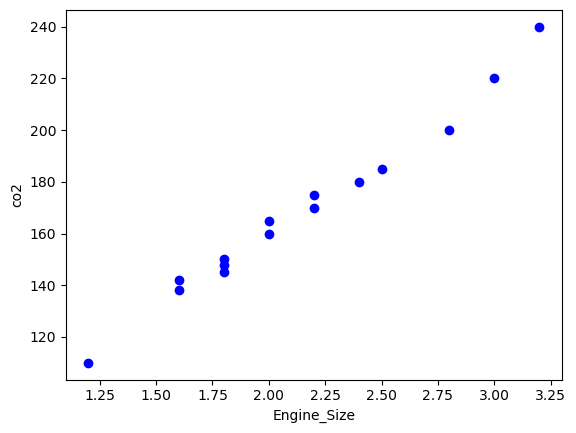

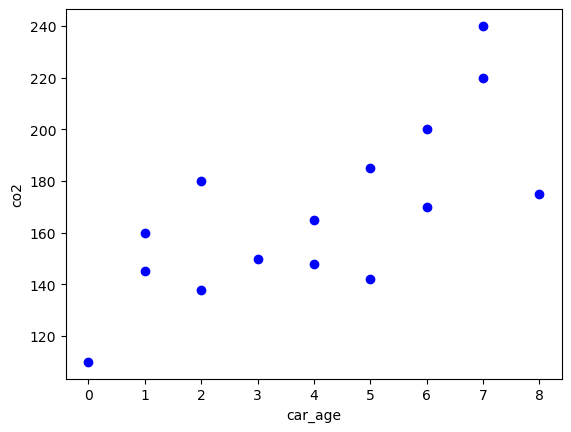

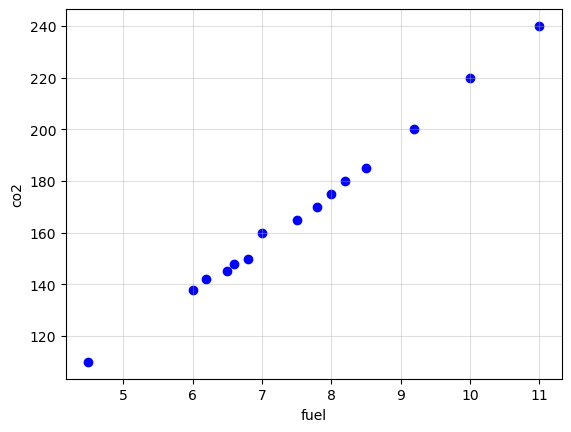

In [5]:
plt.scatter(train.Engine_Size , train.CO2 , c = 'b')
plt.xlabel("Engine_Size")
plt.ylabel('co2')
plt.show()
plt.scatter(train.Car_Age , train.CO2 , c = 'b')
plt.xlabel("car_age")
plt.ylabel('co2')
plt.show()
plt.scatter(train.Fuel_Consumption , train.CO2 , c = 'b')
plt.xlabel("fuel")
plt.ylabel('co2')
plt.grid(True  , alpha=0.4)
plt.show()


In [6]:
from sklearn import linear_model
regr = linear_model.LinearRegression ()
train_x = np.asanyarray(train[['Car_Age', 'Engine_Size','Fuel_Consumption']])
train_y = np.asanyarray(train[['CO2']])
regr.fit(train_x , train_y)
print( 'coef_',regr.coef_)
print('intercept_' , regr.intercept_)

coef_ [[-0.26280894  5.49071646 18.55448487]]
intercept_ [17.08526454]


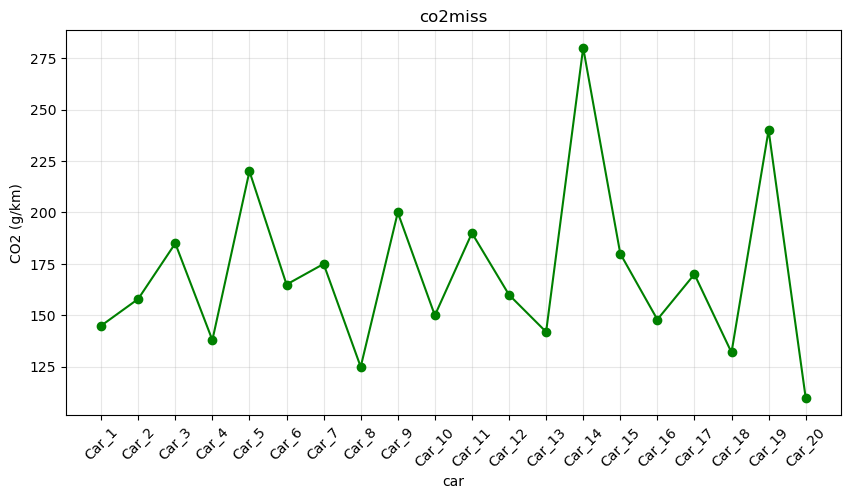

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(cdf.index, cdf['CO2'], 'o-', color='green')
plt.xlabel('car')
plt.ylabel('CO2 (g/km)')
plt.title('co2miss')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
y_hat = regr.predict(test[['Car_Age', 'Engine_Size','Fuel_Consumption']])
x = np.asanyarray(test[['Car_Age', 'Engine_Size','Fuel_Consumption']])
y = np.asanyarray(test['CO2'])
print(np.mean((y_hat - y)**2))
print(regr.score(x , y))

5755.69625552275
0.9861282287515967


C:\Users\ARIO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [9]:
new_data = [[5 , 3 , 9]]
prediction = regr.predict(new_data)
print(prediction)

[[199.2337331]]
